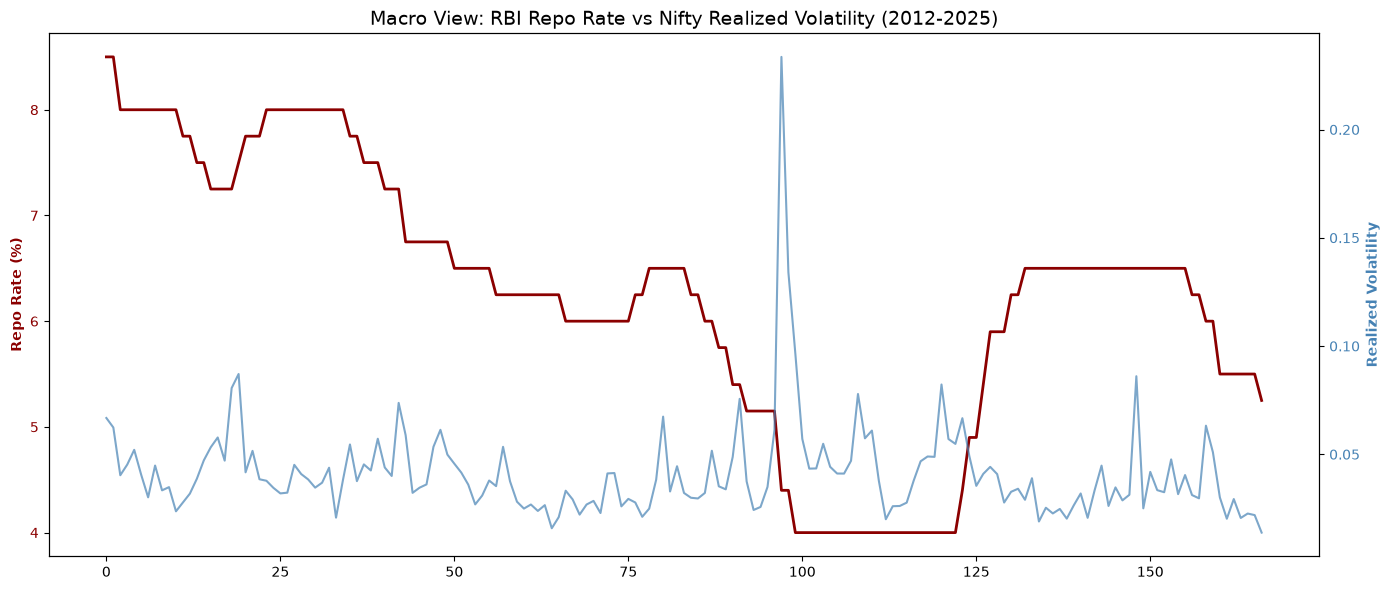

Correlation between Repo Rate Changes and Volatility: -0.3084
(Note: A positive number means larger rate hikes correlate with higher volatility)

--- Event Study: Average Volatility Impact by Regime ---
        Vol_Before  Vol_After  Vol_Change
Regime                                   
Cut       0.044358   0.044486    0.000128
Hike      0.047387   0.037169   -0.010217


/tmp/ipykernel_24395/106052173.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=event_df, x='Regime', y='Vol_Change', palette={'Hike': 'lightcoral', 'Cut': 'lightblue'})


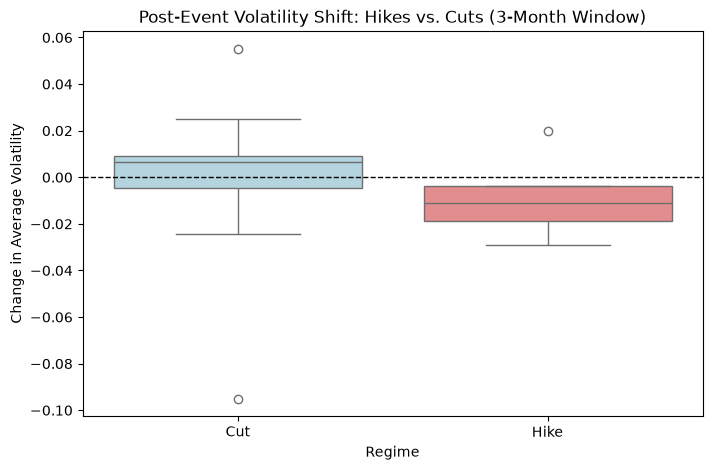

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'master_df' is already in memory from Step 3

filename= "data/master_data.csv"

master_df = pd.read_csv(filename, parse_dates=['Date'])

# ---------------------------------------------------------
# 1. Define Regimes & Calculate Changes
# ---------------------------------------------------------
# Compute month-over-month change in Repo Rate
master_df['Repo_Change'] = master_df['Repo'].diff()

def classify_regime(change):
    if pd.isna(change) or change == 0.0:
        return 'Pause'
    elif change > 0:
        return 'Hike'
    else:
        return 'Cut'

master_df['Regime'] = master_df['Repo_Change'].apply(classify_regime)

# ---------------------------------------------------------
# 2. Plot: Repo Rate vs Nifty Volatility Over Time
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Plotting Repo Rate on the left axis
ax1.plot(master_df.index, master_df['Repo'], color='darkred', label='Repo Rate', linewidth=2)
ax1.set_ylabel('Repo Rate (%)', color='darkred', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='darkred')

# Plotting Volatility on the right axis
ax2.plot(master_df.index, master_df['Volatility'], color='steelblue', alpha=0.7, label='Nifty Volatility', linewidth=1.5)
ax2.set_ylabel('Realized Volatility', color='steelblue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Macro View: RBI Repo Rate vs Nifty Realized Volatility (2012-2025)', fontsize=14)
fig.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Correlation: Rate Changes vs Volatility
# ---------------------------------------------------------
# We isolate periods where the rate actually changed (ignoring pauses for the change correlation)
active_changes = master_df[master_df['Regime'] != 'Pause'].copy()
change_corr = active_changes['Repo_Change'].corr(active_changes['Volatility'])

print(f"Correlation between Repo Rate Changes and Volatility: {change_corr:.4f}")
print("(Note: A positive number means larger rate hikes correlate with higher volatility)")

# ---------------------------------------------------------
# 4. Event Study: 3-Month Window & Regime Segmentation
# ---------------------------------------------------------
events = active_changes.index
event_results = []

for event_date in events:
    loc = master_df.index.get_loc(event_date)
    
    # Ensure we have a 3-month window before and after the event
    if loc >= 3 and loc < len(master_df) - 3:
        # Average volatility 3 months prior
        vol_before = master_df['Volatility'].iloc[loc-3:loc].mean()
        # Average volatility 3 months after (inclusive of the event month if you prefer, but usually strictly after)
        vol_after = master_df['Volatility'].iloc[loc+1:loc+4].mean()
        
        regime = master_df['Regime'].iloc[loc]
        
        event_results.append({
            'Date': event_date,
            'Regime': regime,
            'Vol_Before': vol_before,
            'Vol_After': vol_after,
            'Vol_Change': vol_after - vol_before
        })

event_df = pd.DataFrame(event_results)

print("\n--- Event Study: Average Volatility Impact by Regime ---")
regime_summary = event_df.groupby('Regime')[['Vol_Before', 'Vol_After', 'Vol_Change']].mean()
print(regime_summary)

# Visualizing the Event Study Results
plt.figure(figsize=(8, 5))
sns.boxplot(data=event_df, x='Regime', y='Vol_Change', palette={'Hike': 'lightcoral', 'Cut': 'lightblue'})
plt.title('Post-Event Volatility Shift: Hikes vs. Cuts (3-Month Window)')
plt.ylabel('Change in Average Volatility')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

# Predictive Modeling using Random Forest Classifier

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Feature Engineering
# Target: Next month's volatility
master_df['Target_Vol_Next_Month'] = master_df['Volatility'].shift(-1)

# Features: Current Vol, Repo Rate, Repo Change
# (Dropping the last row since we don't have the 'next month' target for it)
model_df = master_df.dropna(subset=['Target_Vol_Next_Month']).copy()

X = model_df[['Volatility', 'Repo', 'Repo_Change']]
y = model_df['Target_Vol_Next_Month']

# Chronological Train-Test Split (Keep time series integrity)
# Using roughly 80% for training
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 2. The Naive Baseline Model
# Rule: "Next month's volatility will be exactly the same as this month's"
baseline_preds = X_test['Volatility']
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_r2 = r2_score(y_test, baseline_preds)

print("--- Naive Baseline Performance ---")
print(f"MAE: {baseline_mae:.6f}")
print(f"R²:  {baseline_r2:.4f}\n")

# 3. The ML Benchmark: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("--- Random Forest Performance ---")
print(f"MAE: {rf_mae:.6f}")
print(f"R²:  {rf_r2:.4f}")

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print("\n--- Feature Importance ---")
print(importances.sort_values(ascending=False))

--- Naive Baseline Performance ---
MAE: 0.012536
R²:  -0.7531

--- Random Forest Performance ---
MAE: 0.011661
R²:  -0.2765

--- Feature Importance ---
Volatility     0.771233
Repo           0.174859
Repo_Change    0.053907
dtype: float64


Exploratory analysis confirmed a negative correlation between rate hikes and forward 3-month volatility, indicating that market uncertainty compresses following decisive RBI tightening. However, attempting to forecast the exact magnitude of next-month realized volatility using a Random Forest Regressor yielded a negative $R^2$ (-0.27), underperforming a mean-prediction baseline. The model's heavy reliance on lagged volatility (77%) confirms strong volatility clustering. This demonstrates that while policy shifts dictate broader market regimes, exact monthly volatility magnitude on a 167-sample dataset is dominated by autoregressive noise rather than macro-policy variables.

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

# ---------------------------------------------------------
# 1. Re-load and Prep Daily Data
# ---------------------------------------------------------
# Load daily RBI data from file
rbi_df = pd.read_csv('data/rbi_rates.csv')
rbi_df['Effective Date'] = pd.to_datetime(rbi_df['Effective Date'], format='%d-%m-%Y')
rbi_events = rbi_df[['Effective Date', 'Repo']].dropna().copy()
rbi_events.sort_values('Effective Date', inplace=True)
rbi_events.set_index('Effective Date', inplace=True)

# Isolate only the days where the rate actually changed
rbi_events['Repo_Change'] = rbi_events['Repo'].diff()
rbi_events = rbi_events[rbi_events['Repo_Change'] != 0].dropna()

# Re-fetch daily Nifty data
nifty_50 = yf.download("^NSEI", start="2012-02-13", end="2025-12-05", progress=False)

if isinstance(nifty_50.columns, pd.MultiIndex):
    close_prices = nifty_50['Close']['^NSEI']
else:
    close_prices = nifty_50['Close']

nifty_df = pd.DataFrame({'Close': close_prices})

# Ensure the yfinance index is tz-naive to match the RBI dates
nifty_df.index = nifty_df.index.tz_localize(None)

nifty_df['Log_Return'] = np.log(nifty_df['Close'] / nifty_df['Close'].shift(1))

# ---------------------------------------------------------
# 2. Build the Event Study Dataset
# ---------------------------------------------------------
event_data = []
THRESHOLD = 0.015  # Defining a "significant move" as >1.5% in either direction

for event_date, row in rbi_events.iterrows():
    # Find the closest trading day on or after the event
    future_dates = nifty_df.loc[event_date:]
    if len(future_dates) < 6:
        continue # Skip if we don't have 5 days of future data
        
    t0 = future_dates.index[0] # The effective trading day
    t0_loc = nifty_df.index.get_loc(t0)
    
    # Ensure we have enough historical data for the prior 21-day window
    if t0_loc >= 21 and t0_loc + 5 < len(nifty_df):
        prior_window = nifty_df.iloc[t0_loc-21 : t0_loc]
        
        # Features
        prior_trend = (prior_window['Close'].iloc[-1] / prior_window['Close'].iloc[0]) - 1
        prior_vol = prior_window['Log_Return'].std() * np.sqrt(21)
        
        # Target: 5-Day Post-Event Move
        t0_close = nifty_df['Close'].iloc[t0_loc]
        post_close = nifty_df['Close'].iloc[t0_loc + 5]
        post_move = (post_close / t0_close) - 1
        
        # Binary Target
        significant_move = 1 if abs(post_move) > THRESHOLD else 0
        
        event_data.append({
            'Date': t0,
            'Repo_Change': row['Repo_Change'],
            'Prior_Trend': prior_trend,
            'Prior_Volatility': prior_vol,
            'Significant_Move': significant_move
        })

layer3_df = pd.DataFrame(event_data)

# ---------------------------------------------------------
# 3. Model Training & Evaluation
# ---------------------------------------------------------
X = layer3_df[['Repo_Change', 'Prior_Trend', 'Prior_Volatility']]
y = layer3_df['Significant_Move']

# Time-series split (80/20)
split_idx = int(len(layer3_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# --- The Floor: Majority Class Baseline ---
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

print("--- Baseline (Majority Class) ---")
print(f"Accuracy: {accuracy_score(y_test, dummy_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, dummy_preds, zero_division=0):.4f}\n")

# --- Benchmark 1: Logistic Regression ---
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
log_preds = log_reg.predict(X_test)

print("--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, log_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, log_preds, zero_division=0):.4f}\n")

# --- Benchmark 2: Random Forest ---
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_clf.fit(X_train, y_train)
rf_preds = rf_clf.predict(X_test)

print("--- Random Forest Classifier ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_preds, zero_division=0):.4f}")

--- Baseline (Majority Class) ---
Accuracy: 0.4286
F1 Score: 0.6000

--- Logistic Regression ---
Accuracy: 0.4286
F1 Score: 0.6000

--- Random Forest Classifier ---
Accuracy: 0.2857
F1 Score: 0.4444


A binary classification framework was deployed to predict >1.5% Nifty movements in the 5-day post-announcement window. Both Logistic Regression and Random Forest failed to beat a majority-class baseline (Acc: 0.42). Rather than a technical failure, this confirms the efficiency of the flexible inflation targeting framework: markets effectively price in policy shifts prior to the announcement, rendering post-event directional movement as statistically unpredictable noise. Tree-based models heavily overfit the small sample of active rate-change events, demonstrating the limitations of standard ML on low-frequency macro data.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

# ---------------------------------------------------------
# 1. Re-load and Prep Daily Data
# ---------------------------------------------------------
# Load daily RBI data from file
rbi_df = pd.read_csv('data/rbi_rates.csv')
rbi_df['Effective Date'] = pd.to_datetime(rbi_df['Effective Date'], format='%d-%m-%Y')
rbi_events = rbi_df[['Effective Date', 'Repo']].dropna().copy()
rbi_events.sort_values('Effective Date', inplace=True)
rbi_events.set_index('Effective Date', inplace=True)

# Isolate only the days where the rate actually changed
rbi_events['Repo_Change'] = rbi_events['Repo'].diff()
rbi_events = rbi_events[rbi_events['Repo_Change'] != 0].dropna()

# Re-fetch daily Nifty data
nifty_50 = yf.download("^NSEI", start="2012-02-13", end="2025-12-05", progress=False)

if isinstance(nifty_50.columns, pd.MultiIndex):
    close_prices = nifty_50['Close']['^NSEI']
else:
    close_prices = nifty_50['Close']

nifty_df = pd.DataFrame({'Close': close_prices})

# Ensure the yfinance index is tz-naive to match the RBI dates
nifty_df.index = nifty_df.index.tz_localize(None)

nifty_df['Log_Return'] = np.log(nifty_df['Close'] / nifty_df['Close'].shift(1))

# ---------------------------------------------------------
# 2. Build the Event Study Dataset
# ---------------------------------------------------------
event_data = []
THRESHOLD = 0.01  # Defining a "significant move" as >1.0% in either direction

for event_date, row in rbi_events.iterrows():
    # Find the closest trading day on or after the event
    future_dates = nifty_df.loc[event_date:]
    if len(future_dates) < 6:
        continue # Skip if we don't have 5 days of future data
        
    t0 = future_dates.index[0] # The effective trading day
    t0_loc = nifty_df.index.get_loc(t0)
    
    # Ensure we have enough historical data for the prior 21-day window
    if t0_loc >= 21 and t0_loc + 5 < len(nifty_df):
        prior_window = nifty_df.iloc[t0_loc-21 : t0_loc]
        
        # Features
        prior_trend = (prior_window['Close'].iloc[-1] / prior_window['Close'].iloc[0]) - 1
        prior_vol = prior_window['Log_Return'].std() * np.sqrt(21)
        
        # Target: 5-Day Post-Event Move
        t0_close = nifty_df['Close'].iloc[t0_loc]
        post_close = nifty_df['Close'].iloc[t0_loc + 5]
        post_move = (post_close / t0_close) - 1
        
        # Binary Target
        significant_move = 1 if abs(post_move) > THRESHOLD else 0
        
        event_data.append({
            'Date': t0,
            'Repo_Change': row['Repo_Change'],
            'Prior_Trend': prior_trend,
            'Prior_Volatility': prior_vol,
            'Significant_Move': significant_move
        })

layer3_df = pd.DataFrame(event_data)

# ---------------------------------------------------------
# 3. Model Training & Evaluation
# ---------------------------------------------------------
X = layer3_df[['Repo_Change', 'Prior_Trend', 'Prior_Volatility']]
y = layer3_df['Significant_Move']

# Time-series split (80/20)
split_idx = int(len(layer3_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# --- The Floor: Majority Class Baseline ---
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

print("--- Baseline (Majority Class) ---")
print(f"Accuracy: {accuracy_score(y_test, dummy_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, dummy_preds, zero_division=0):.4f}\n")

# --- Benchmark 1: Logistic Regression ---
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
log_preds = log_reg.predict(X_test)

print("--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, log_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, log_preds, zero_division=0):.4f}\n")

# --- Benchmark 2: Random Forest ---
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_clf.fit(X_train, y_train)
rf_preds = rf_clf.predict(X_test)

print("--- Random Forest Classifier ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_preds, zero_division=0):.4f}")

--- Baseline (Majority Class) ---
Accuracy: 0.5714
F1 Score: 0.7273

--- Logistic Regression ---
Accuracy: 0.5714
F1 Score: 0.7273

--- Random Forest Classifier ---
Accuracy: 0.5714
F1 Score: 0.7273


# Volatility Regime Classification

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import TimeSeriesSplit

# ---------------------------------------------------------
# 1. Data Loading & Feature Engineering
# ---------------------------------------------------------
master_df = pd.read_csv('data/master_data.csv', parse_dates=['Date']).set_index('Date')

# Recalculate Repo_Change
master_df['Repo_Change'] = master_df['Repo'].diff()

# Define "High Volatility" using a 12-month rolling median.
master_df['Rolling_Median_Vol'] = master_df['Volatility'].rolling(window=12).median()

# The Target: Will next month's volatility be strictly higher than the local median?
master_df['Next_Month_Vol'] = master_df['Volatility'].shift(-1)

# Drop rows with NaN (first 11 months for rolling median, and the last month for shift)
model_df = master_df.dropna().copy()

model_df['Target_High_Vol'] = (model_df['Next_Month_Vol'] > model_df['Rolling_Median_Vol']).astype(int)
model_df['Current_Vol_Regime'] = (model_df['Volatility'] > model_df['Rolling_Median_Vol']).astype(int)

# Select features
X = model_df[['Volatility', 'Repo', 'Repo_Change', 'Current_Vol_Regime']]
y = model_df['Target_High_Vol']

# ---------------------------------------------------------
# 2. Walk-Forward Validation (Time Series Split)
# ---------------------------------------------------------
# We use 5 chronological splits. The model trains on past data to predict future data.
tscv = TimeSeriesSplit(n_splits=5)

baseline_acc, baseline_f1 = [], []
logreg_acc, logreg_f1 = [], []
rf_acc, rf_f1 = [], []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # --- Benchmark 1: Autoregressive Baseline ---
    # Rule: "Next month's regime will be exactly the same as this month's regime"
    baseline_preds = X_test['Current_Vol_Regime']
    baseline_acc.append(accuracy_score(y_test, baseline_preds))
    baseline_f1.append(f1_score(y_test, baseline_preds, zero_division=0))
    
    # --- Benchmark 2: Logistic Regression ---
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(X_train, y_train)
    lr_preds = log_reg.predict(X_test)
    logreg_acc.append(accuracy_score(y_test, lr_preds))
    logreg_f1.append(f1_score(y_test, lr_preds, zero_division=0))
    
    # --- Benchmark 3: Random Forest Classifier ---
    rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
    rf.fit(X_train, y_train)
    rf_preds = rf.predict(X_test)
    rf_acc.append(accuracy_score(y_test, rf_preds))
    rf_f1.append(f1_score(y_test, rf_preds, zero_division=0))

# ---------------------------------------------------------
# 3. Model Evaluation Aggregation
# ---------------------------------------------------------
print("=== Walk-Forward Validation Results (5 Folds) ===\n")

print("1. Naive Autoregressive Baseline (Current Regime = Next Regime)")
print(f"   Average Accuracy: {np.mean(baseline_acc):.4f}")
print(f"   Average F1-Score: {np.mean(baseline_f1):.4f}\n")

print("2. Logistic Regression")
print(f"   Average Accuracy: {np.mean(logreg_acc):.4f}")
print(f"   Average F1-Score: {np.mean(logreg_f1):.4f}\n")

print("3. Random Forest Classifier")
print(f"   Average Accuracy: {np.mean(rf_acc):.4f}")
print(f"   Average F1-Score: {np.mean(rf_f1):.4f}")

=== Walk-Forward Validation Results (5 Folds) ===

1. Naive Autoregressive Baseline (Current Regime = Next Regime)
   Average Accuracy: 0.7040
   Average F1-Score: 0.6564

2. Logistic Regression
   Average Accuracy: 0.5440
   Average F1-Score: 0.5053

3. Random Forest Classifier
   Average Accuracy: 0.4400
   Average F1-Score: 0.4033


# Abnormal Volatility Windows

=== Abnormal Volatility Around MPC Events (Annualized) ===
        Pre_Abnormal  Post_Abnormal
Regime                             
Cut         0.035796      -0.002555
Hike       -0.025718      -0.027988


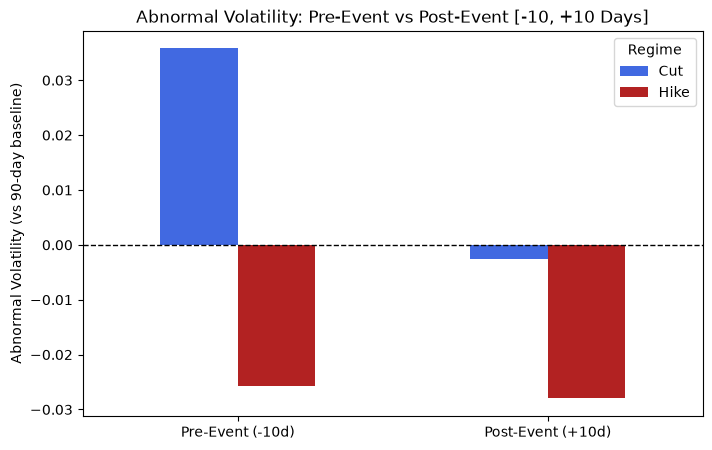

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Daily Data
rbi_df = pd.read_csv('data/rbi_rates.csv')
rbi_df['Effective Date'] = pd.to_datetime(rbi_df['Effective Date'], format='%d-%m-%Y')
rbi_events = rbi_df[['Effective Date', 'Repo']].dropna().copy()
rbi_events.sort_values('Effective Date', inplace=True)
rbi_events.set_index('Effective Date', inplace=True)

# Isolate rate changes
rbi_events['Repo_Change'] = rbi_events['Repo'].diff()
rbi_events = rbi_events[rbi_events['Repo_Change'] != 0].dropna()
rbi_events['Regime'] = rbi_events['Repo_Change'].apply(lambda x: 'Hike' if x > 0 else 'Cut')

# Fetch Nifty Data
nifty_df = yf.download("^NSEI", start="2011-01-01", end="2025-12-05", progress=False)
if isinstance(nifty_df.columns, pd.MultiIndex):
    nifty_df = pd.DataFrame({'Close': nifty_df['Close']['^NSEI']})
nifty_df.index = nifty_df.index.tz_localize(None)
nifty_df['Log_Return'] = np.log(nifty_df['Close'] / nifty_df['Close'].shift(1))

# 2. Calculate Abnormal Volatility Event Windows
results = []
for event_date, row in rbi_events.iterrows():
    try:
        # --- CORRECTED LINE: Using searchsorted instead of get_loc ---
        event_loc = nifty_df.index.searchsorted(event_date)
        
        # Ensure sufficient history and future data
        if event_loc >= 90 and event_loc + 10 < len(nifty_df):
            # Baseline Volatility (-90 to -11 days)
            base_returns = nifty_df['Log_Return'].iloc[event_loc-90 : event_loc-10]
            base_vol = base_returns.std() * np.sqrt(252) # Annualized
            
            # Pre-Event Volatility (-10 to -1 days)
            pre_returns = nifty_df['Log_Return'].iloc[event_loc-10 : event_loc]
            pre_vol = pre_returns.std() * np.sqrt(252)
            
            # Post-Event Volatility (0 to +10 days)
            post_returns = nifty_df['Log_Return'].iloc[event_loc : event_loc+11]
            post_vol = post_returns.std() * np.sqrt(252)
            
            results.append({
                'Date': event_date,
                'Regime': row['Regime'],
                'Baseline_Vol': base_vol,
                'Pre_Event_Vol': pre_vol,
                'Post_Event_Vol': post_vol,
                'Pre_Abnormal': pre_vol - base_vol,
                'Post_Abnormal': post_vol - base_vol
            })
    except Exception as e:
        print(f"Skipping {event_date} due to error: {e}")
        continue

event_study_df = pd.DataFrame(results)

# 3. Aggregate and Visualize
print("=== Abnormal Volatility Around MPC Events (Annualized) ===")
summary = event_study_df.groupby('Regime')[['Pre_Abnormal', 'Post_Abnormal']].mean()
print(summary)

# Plotting
summary.T.plot(kind='bar', figsize=(8, 5), color=['royalblue', 'firebrick'])
plt.title('Abnormal Volatility: Pre-Event vs Post-Event [-10, +10 Days]')
plt.ylabel('Abnormal Volatility (vs 90-day baseline)')
plt.xticks(ticks=[0, 1], labels=['Pre-Event (-10d)', 'Post-Event (+10d)'], rotation=0)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

# Finance-Native Modeling (GJR-GARCH)

=== GJR-GARCH Model Summary ===
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                       Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -4754.47
Distribution:      Standardized Student's t   AIC:                           9520.95
Method:                  Maximum Likelihood   BIC:                           9558.18
                                              No. Observations:                 3660
Date:                      Thu, Sep 03 2026   Df Residuals:                     3659
Time:                              23:15:17   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
-------------------------------------------------

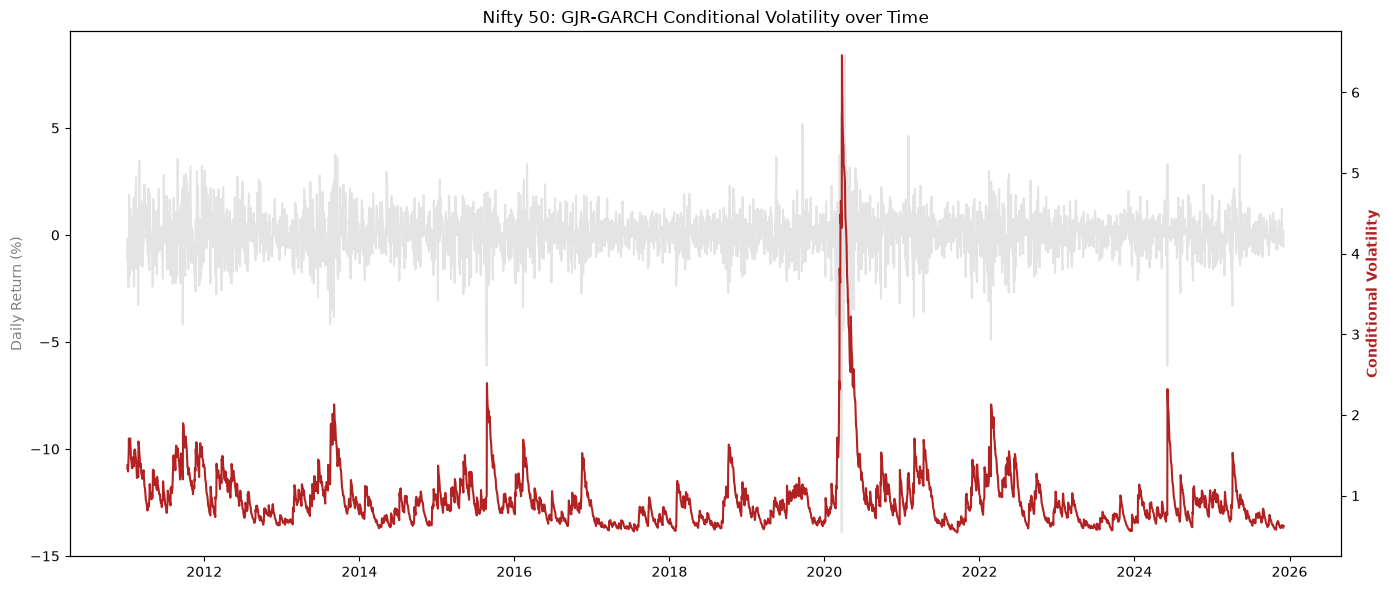

In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from arch import arch_model

# 1. Fetch Nifty Data (Using the same timeframe)
nifty_df = yf.download("^NSEI", start="2011-01-01", end="2025-12-05", progress=False)
if isinstance(nifty_df.columns, pd.MultiIndex):
    nifty_df = pd.DataFrame({'Close': nifty_df['Close']['^NSEI']})
nifty_df.index = nifty_df.index.tz_localize(None)

# Calculate daily percentage returns (multiplying by 100 is required for arch optimization)
nifty_df['Return'] = 100 * np.log(nifty_df['Close'] / nifty_df['Close'].shift(1))
nifty_df = nifty_df.dropna()

# 2. Define and Fit the GJR-GARCH Model
# p=1 (Lagged variance), o=1 (Asymmetric shock term), q=1 (Lagged residual)
# dist='t' uses a Student's t-distribution to account for heavy tails (fat tails) in financial data
gjr_garch = arch_model(nifty_df['Return'], vol='GARCH', p=1, o=1, q=1, dist='t')

# Fit the model (disp='off' hides the optimization iterations)
res = gjr_garch.fit(disp='off')

print("=== GJR-GARCH Model Summary ===")
print(res.summary())

# 3. Extract Conditional Volatility
nifty_df['Conditional_Vol'] = res.conditional_volatility

# 4. Visualize the Conditional Volatility vs Market Returns
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(nifty_df.index, nifty_df['Return'], color='lightgray', label='Daily Returns', alpha=0.6)
ax1.set_ylabel('Daily Return (%)', color='gray')

ax2 = ax1.twinx()
ax2.plot(nifty_df.index, nifty_df['Conditional_Vol'], color='firebrick', label='GJR-GARCH Volatility', linewidth=1.5)
ax2.set_ylabel('Conditional Volatility', color='firebrick', fontweight='bold')

plt.title('Nifty 50: GJR-GARCH Conditional Volatility over Time')
fig.tight_layout()
plt.show()